In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# 데이터 불러오기
df = pd.read_csv("output.csv")

In [2]:
# 입력 / 출력 분리
X = df[["tADS", "PL", "v0", "t_press", "t_depress"]]

y_purity = df["CO2_purity"]
y_recovery = df["CO2_recovery"]

In [5]:
# 모델 정의
model_purity = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model_recovery = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

In [6]:
# 학습
model_purity.fit(X, y_purity)
model_recovery.fit(X, y_recovery)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [7]:
# 중요도 추출
importance_purity = model_purity.feature_importances_
importance_recovery = model_recovery.feature_importances_

features = X.columns

# 정렬
idx_purity = np.argsort(importance_purity)[::-1]
idx_recovery = np.argsort(importance_recovery)[::-1]


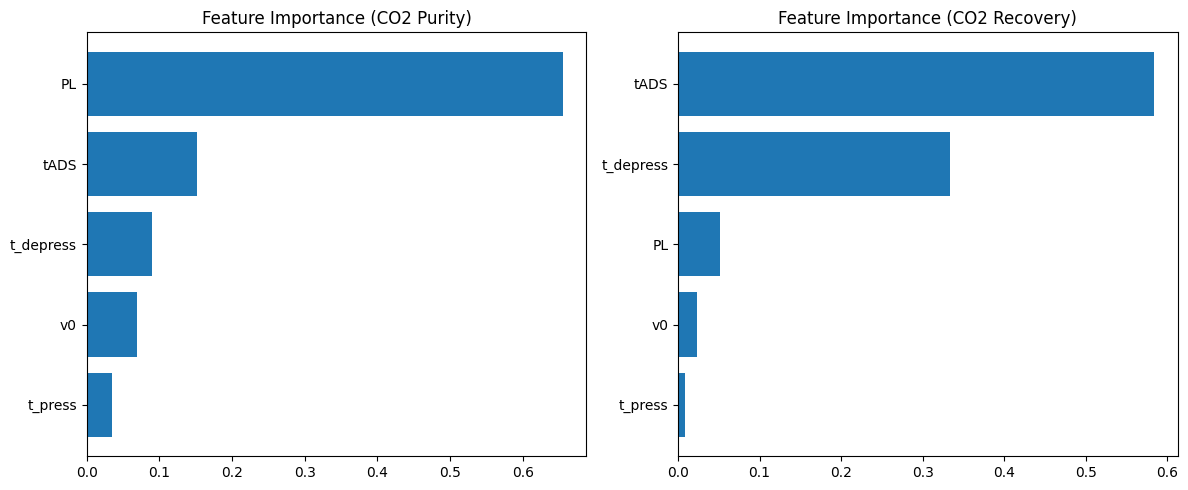

In [8]:
# 시각화
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.barh(features[idx_purity], importance_purity[idx_purity])
plt.title("Feature Importance (CO2 Purity)")
plt.gca().invert_yaxis()

plt.subplot(1,2,2)
plt.barh(features[idx_recovery], importance_recovery[idx_recovery])
plt.title("Feature Importance (CO2 Recovery)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [9]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model_purity, X, y_purity,
    n_repeats=10,
    random_state=42
)

for i in result.importances_mean.argsort()[::-1]:
    print(features[i], result.importances_mean[i])

PL 1.5348282308021064
tADS 0.299778062650845
v0 0.04843716124936074
t_press 0.016252428203824408
t_depress 0.010132387212562256
